# Perfilamiento táctico de jugadores de pádel mediante clustering no supervisado

Este notebook explora y perfila los estilos de juego de jugadores de pádel (ofensivo, defensivo, balanceado) usando técnicas de clustering no supervisado sobre estadísticas de partidos.  
El objetivo es identificar agrupamientos que representen diferentes perfiles tácticos y validar los resultados tanto desde la perspectiva estadística como deportiva, comparando varios métodos clásicos y alternativos.

---

## Introducción

El análisis táctico en deportes como el pádel se puede enriquecer empleando modelos de aprendizaje no supervisado, capaces de descubrir patrones y subgrupos en grandes volúmenes de datos sin necesidad de etiquetas previas.  
En esta investigación se seleccionan las variables que mejor describen el comportamiento en partido, se prueban diversos algoritmos de clustering,  y se evalúa la separación y representatividad de los grupos obtenidos.  
Se incluyen comparaciones, justificaciones y propuestas de mejora para continuar profundizando el perfilamiento de jugadores a nivel profesional.




## 1. Librerías a importar

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 2. Preprocesamiento de datos

En esta sección se realiza la carga inicial, análisis y limpieza del dataset, asegurando calidad y consistencia para los algoritmos de clustering.



### 2.1 Carga y exploración inicial

Se importa el dataset original y se explora su estructura: dimensiones, columnas, tipos de datos y primeras filas.


In [6]:
import pandas as pd

df = pd.read_csv("padel.csv")

print("Dimensiones del dataset:", df.shape)
display(df.head())

print("\nNombres y tipos de columnas:")
print(df.dtypes)


# Estadísticas generales
print("\nResumen estadístico:")
display(df.describe(include='all'))


C:\Users\Manuel Castillo\AppData\Local\Temp\ipykernel_23692\1323828240.py:3: DtypeWarning: Columns (6,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("padel.csv")


Dimensiones del dataset: (540300, 30)


,frame_idx,duration,total_frames,video_duration,player_id,player_name,team,zone,ball_position_x,ball_position_y,...,player_speed_mps,prev_speed,player_acceleration_mps2,ball_position_x_prev,ball_position_y_prev,ball_displacement,ball_speed_mps,time_since_last_hit,partido,punto
0,0,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,top,right_box,3.24,17.111111,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Partido 27,10.0
1,1,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,top,right_box,3.24,17.111111,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Partido 27,10.0
2,2,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,top,right_box,3.24,17.111111,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,Partido 27,10.0
3,3,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,top,right_box,3.24,17.111111,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,Partido 27,10.0
4,4,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,top,right_box,3.24,17.111111,...,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,Partido 27,10.0



Nombres y tipos de columnas:
frame_idx                          int64
duration                         float64
total_frames                       int64
video_duration                   float64
player_id                          int64
player_name                       object
team                              object
zone                              object
ball_position_x                  float64
ball_position_y                  float64
player_position_x                float64
player_position_y                float64
distance_ball_to_net             float64
distance_player_to_ball_m        float64
distance_player_to_net_m         float64
distance_player_to_teammate_m    float64
player_hits_ball                    bool
prev_x                           float64
prev_y                           float64
player_displacement              float64
player_speed_mps                 float64
prev_speed                       float64
player_acceleration_mps2         float64
ball_position_x_prev       

,frame_idx,duration,total_frames,video_duration,player_id,player_name,team,zone,ball_position_x,ball_position_y,...,player_speed_mps,prev_speed,player_acceleration_mps2,ball_position_x_prev,ball_position_y_prev,ball_displacement,ball_speed_mps,time_since_last_hit,partido,punto
count,540300.000000,540300.000000,540300.000000,540300.000000,540300.000000,519424,159382,540300,540300.000000,540300.000000,...,537585.000000,535092.000000,535092.000000,430743.000000,430743.000000,430743.0,430743.0,16361.000000,540300.0,519424.000000
unique,NaN,NaN,NaN,NaN,NaN,331,2,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.0,NaN
top,NaN,NaN,NaN,NaN,NaN,María José Cifuentes,bottom,left_box,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,NaN
freq,NaN,NaN,NaN,NaN,NaN,18532,81394,224013,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36172.0,NaN
mean,236.541947,0.024876,471.026461,11.333344,14.085208,NaN,NaN,NaN,4.239575,10.316255,...,1.585811,1.580268,-0.205568,4.208803,10.380320,0.0,0.0,2.877869,NaN,5.763627
std,208.280158,0.008320,273.626478,7.086376,44.588668,NaN,NaN,NaN,2.549286,4.537078,...,12.787924,12.776415,892.103624,2.576104,4.556784,0.0,0.0,3.367727,NaN,3.276996
min,0.000000,0.016667,72.000000,1.200000,1.000000,NaN,NaN,NaN,0.560000,0.311111,...,0.000000,0.000000,-44598.638900,0.560000,0.311111,0.0,0.0,0.000000,NaN,1.000000
25%,88.000000,0.016667,278.000000,6.566667,2.000000,NaN,NaN,NaN,2.200000,6.488889,...,0.000000,0.000000,0.000000,2.160000,6.488889,0.0,0.0,0.616667,NaN,3.000000
50%,181.000000,0.016773,420.000000,9.150000,3.000000,NaN,NaN,NaN,3.520000,10.622222,...,0.000000,0.000000,0.000000,3.520000,10.755556,0.0,0.0,1.766667,NaN,6.000000
75%,325.000000,0.033333,597.000000,14.833333,7.000000,NaN,NaN,NaN,6.200000,13.866667,...,1.697056,1.697056,0.000000,6.160000,13.955556,0.0,0.0,3.950000,NaN,9.000000


### 2.2 Diagnóstico de nulos y estadísticas generales

Se calcula el porcentaje de valores nulos por columna y se presenta un resumen estadístico, identificando variables problemáticas y rangos sospechosos.



In [7]:
# Porcentaje de nulos por columna
null_percent = (df.isnull().mean() * 100).round(2)
print("\nPorcentaje de nulos por columna:")
display(null_percent)

# Estadísticas generales
print("\nResumen estadístico:")
display(df.describe(include='all'))



Porcentaje de nulos por columna:


frame_idx                         0.00
duration                          0.00
total_frames                      0.00
video_duration                    0.00
player_id                         0.00
player_name                       3.86
team                             70.50
zone                              0.00
ball_position_x                   0.00
ball_position_y                   0.00
player_position_x                 0.00
player_position_y                 0.00
distance_ball_to_net              0.00
distance_player_to_ball_m         0.00
distance_player_to_net_m          0.00
distance_player_to_teammate_m    52.29
player_hits_ball                  0.00
prev_x                            0.50
prev_y                            0.50
player_displacement               0.50
player_speed_mps                  0.50
prev_speed                        0.96
player_acceleration_mps2          0.96
ball_position_x_prev             20.28
ball_position_y_prev             20.28
ball_displacement        


Resumen estadístico:


,frame_idx,duration,total_frames,video_duration,player_id,player_name,team,zone,ball_position_x,ball_position_y,...,player_speed_mps,prev_speed,player_acceleration_mps2,ball_position_x_prev,ball_position_y_prev,ball_displacement,ball_speed_mps,time_since_last_hit,partido,punto
count,540300.000000,540300.000000,540300.000000,540300.000000,540300.000000,519424,159382,540300,540300.000000,540300.000000,...,537585.000000,535092.000000,535092.000000,430743.000000,430743.000000,430743.0,430743.0,16361.000000,540300.0,519424.000000
unique,NaN,NaN,NaN,NaN,NaN,331,2,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.0,NaN
top,NaN,NaN,NaN,NaN,NaN,María José Cifuentes,bottom,left_box,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,NaN
freq,NaN,NaN,NaN,NaN,NaN,18532,81394,224013,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36172.0,NaN
mean,236.541947,0.024876,471.026461,11.333344,14.085208,NaN,NaN,NaN,4.239575,10.316255,...,1.585811,1.580268,-0.205568,4.208803,10.380320,0.0,0.0,2.877869,NaN,5.763627
std,208.280158,0.008320,273.626478,7.086376,44.588668,NaN,NaN,NaN,2.549286,4.537078,...,12.787924,12.776415,892.103624,2.576104,4.556784,0.0,0.0,3.367727,NaN,3.276996
min,0.000000,0.016667,72.000000,1.200000,1.000000,NaN,NaN,NaN,0.560000,0.311111,...,0.000000,0.000000,-44598.638900,0.560000,0.311111,0.0,0.0,0.000000,NaN,1.000000
25%,88.000000,0.016667,278.000000,6.566667,2.000000,NaN,NaN,NaN,2.200000,6.488889,...,0.000000,0.000000,0.000000,2.160000,6.488889,0.0,0.0,0.616667,NaN,3.000000
50%,181.000000,0.016773,420.000000,9.150000,3.000000,NaN,NaN,NaN,3.520000,10.622222,...,0.000000,0.000000,0.000000,3.520000,10.755556,0.0,0.0,1.766667,NaN,6.000000
75%,325.000000,0.033333,597.000000,14.833333,7.000000,NaN,NaN,NaN,6.200000,13.866667,...,1.697056,1.697056,0.000000,6.160000,13.955556,0.0,0.0,3.950000,NaN,9.000000


### 2.3 Limpieza y eliminación de columnas no útiles

Se eliminan aquellas columnas con alto porcentaje de nulos (>50%) y variables irrelevantes para el análisis táctico, reduciendo el riesgo de sesgo y errores en el modelo.


In [8]:
# Identificamos columnas con más del 50% de nulos
cols_high_nulls = null_percent[null_percent > 50].index.tolist()
print("Columnas con >50% nulos:", cols_high_nulls)

# Eliminamos esas columnas
df_clean = df.drop(columns=cols_high_nulls)
print("Dimensiones después de eliminar columnas muy nulas:", df_clean.shape)


Columnas con >50% nulos: ['team', 'distance_player_to_teammate_m', 'time_since_last_hit']
Dimensiones después de eliminar columnas muy nulas: (540300, 27)


### 2.4 Imputación y relleno de valores faltantes

Los valores faltantes en variables importantes se rellenan usando media aritmética, forward fill (para variables secuenciales) y ceros (para columnas de movimiento de la bola), mejorando la integridad del dataset.



In [9]:
df_clean = df.copy()

cols_to_drop = [
    "team",                           # 70% nulos
    "distance_player_to_teammate_m",  # 52%
    "time_since_last_hit"             # 97%
]

df_clean = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns])
print("Columnas eliminadas:", [c for c in cols_to_drop if c in df_clean.columns])

ball_prev_cols = ["ball_position_x_prev", "ball_position_y_prev"]
ball_motion_cols = ["ball_displacement", "ball_speed_mps"]

for col in ball_prev_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(method="ffill")

for col in ball_motion_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

small_nulls_mean = [
    "player_displacement",
    "player_speed_mps",
    "prev_speed",
    "player_acceleration_mps2"
]

small_nulls_ffill = [
    "prev_x",
    "prev_y"
]

# Imputar por media
for col in small_nulls_mean:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

# Forward fill para valores previos del jugador
for col in small_nulls_ffill:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(method="ffill")

# Rellenar nombre de jugador y punto (si existen)
if "player_name" in df_clean.columns:
    df_clean["player_name"] = df_clean["player_name"].fillna(method="ffill")

if "punto" in df_clean.columns:
    df_clean["punto"] = df_clean["punto"].fillna(method="ffill")

print("Dataset después de imputación:")
display(df_clean.head())

print("\nNulos restantes:")
display(df_clean.isnull().sum())


Columnas eliminadas: []
Dataset después de imputación:


C:\Users\Manuel Castillo\AppData\Local\Temp\ipykernel_23692\4234885455.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean[col] = df_clean[col].fillna(method="ffill")
C:\Users\Manuel Castillo\AppData\Local\Temp\ipykernel_23692\4234885455.py:43: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean[col] = df_clean[col].fillna(method="ffill")
C:\Users\Manuel Castillo\AppData\Local\Temp\ipykernel_23692\4234885455.py:47: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_clean["player_name"] = df_clean["player_name"].fillna(method="ffill")
C:\Users\Manuel Castillo\AppData\Local\Temp\ipykernel_23692\4234885455.py:50: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffi

,frame_idx,duration,total_frames,video_duration,player_id,player_name,zone,ball_position_x,ball_position_y,player_position_x,...,player_displacement,player_speed_mps,prev_speed,player_acceleration_mps2,ball_position_x_prev,ball_position_y_prev,ball_displacement,ball_speed_mps,partido,punto
0,0,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,right_box,3.24,17.111111,1.48,...,0.03825,1.585811,1.580268,-0.205568,NaN,NaN,0.0,0.0,Partido 27,10.0
1,1,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,right_box,3.24,17.111111,1.48,...,0.00000,0.000000,1.580268,-0.205568,NaN,NaN,0.0,0.0,Partido 27,10.0
2,2,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,right_box,3.24,17.111111,1.48,...,0.00000,0.000000,0.000000,0.000000,NaN,NaN,0.0,0.0,Partido 27,10.0
3,3,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,right_box,3.24,17.111111,1.48,...,0.00000,0.000000,0.000000,0.000000,NaN,NaN,0.0,0.0,Partido 27,10.0
4,4,0.033333,625,20.833333,1,Luis Jorge Garcia Camargo,right_box,3.24,17.111111,1.48,...,0.00000,0.000000,0.000000,0.000000,NaN,NaN,0.0,0.0,Partido 27,10.0



Nulos restantes:


frame_idx                      0
duration                       0
total_frames                   0
video_duration                 0
player_id                      0
player_name                    0
zone                           0
ball_position_x                0
ball_position_y                0
player_position_x              0
player_position_y              0
distance_ball_to_net           0
distance_player_to_ball_m      0
distance_player_to_net_m       0
player_hits_ball               0
prev_x                         1
prev_y                         1
player_displacement            0
player_speed_mps               0
prev_speed                     0
player_acceleration_mps2       0
ball_position_x_prev         625
ball_position_y_prev         625
ball_displacement              0
ball_speed_mps                 0
partido                        0
punto                          0
dtype: int64

### 2.5 Filtrado físico y deportivo

Se eliminan registros corruptos y valores irreales, como IDs de jugador automático y medidas que exceden los límites físicos razonables para el deporte.


In [10]:
player_rows = df_clean[df_clean["player_name"].str.startswith("Player_")].shape[0]
total_filas = df_clean.shape[0]
porcentaje_filas = player_rows / total_filas * 100


print(f"📌 Porcentaje de filas corruptas: {porcentaje_filas:.2f}%")


print(df_clean.shape)
df_clean = df_clean[~df_clean["player_name"].str.startswith("Player_")]
print("Después de eliminar Player_:", df_clean.shape)

df_clean = df_clean[
    (df_clean["player_speed_mps"] <= 12) &               # velocidad humana
    (df_clean["distance_player_to_net_m"] <= 12)         # tamaño real de la cancha
]

print("Después del filtrado físico:", df_clean.shape)

📌 Porcentaje de filas corruptas: 39.47%
(540300, 27)
Después de eliminar Player_: (327066, 27)
Después del filtrado físico: (321773, 27)


### 2.6 Agrupación y resumen por jugador-partido

Se agrupan los datos limpios por jugador y partido, calculando medias y sumas de variables relevantes para caracterizar estilos de juego.



In [11]:
# Definimos las variables a resumir y su función de agregación
agg_dict = {
    "distance_player_to_net_m": "mean",
    "distance_player_to_ball_m": "mean",
    "player_position_x": "mean",
    "player_position_y": "mean",
    "player_speed_mps": ["mean", "max"],
    "player_acceleration_mps2": "mean",
    "player_displacement": "mean",
    "player_hits_ball": "sum",
    "punto": "nunique",
    "frame_idx": "max",
    "distance_ball_to_net": "mean",
    "ball_speed_mps": "mean"
}

df_match = df_clean.groupby(["player_name", "partido"]).agg(agg_dict)

# Cambiar nombres de columnas múltiples
df_match.columns = ['_'.join(col).strip() for col in df_match.columns.values]
df_match.reset_index(inplace=True)

print("Shape de la tabla agregada jugador-partido:", df_match.shape)
display(df_match.head())


Shape de la tabla agregada jugador-partido: (113, 15)


,player_name,partido,distance_player_to_net_m_mean,distance_player_to_ball_m_mean,player_position_x_mean,player_position_y_mean,player_speed_mps_mean,player_speed_mps_max,player_acceleration_mps2_mean,player_displacement_mean,player_hits_ball_sum,punto_nunique,frame_idx_max,distance_ball_to_net_mean,ball_speed_mps_mean
0,Andrea Julieth Sosa Rodriguez,17,2.899454,5.884212,3.577424,3.577424,0.425117,11.879394,-16.651618,0.014110,11,12,341,4.274484,0.0
1,Andrea Julieth Sosa Rodriguez,23,8.358809,11.923196,3.287687,3.287687,0.480396,11.879394,-25.400353,0.015954,16,9,326,4.201447,0.0
2,Andrea Julieth Sosa Rodriguez,Partido 29,3.342596,7.785804,8.127391,8.127391,0.779957,11.879394,-26.162787,0.025959,0,12,700,4.145949,0.0
3,Carlos Felipe Andrade Sáenz,19,8.427769,10.739759,-2.220524,-2.220524,1.825838,11.879394,-127.766626,0.060819,5,9,507,4.111161,0.0
4,Carlos Felipe Andrade Sáenz,21,4.280667,4.777936,3.742924,3.742924,0.482242,11.879394,-52.015042,0.016026,13,10,515,4.807844,0.0


### 2.7 Carga y Limpieza de jugadores.csv

In [19]:
# ============================================================
# 1. Cargar jugadores.csv (limpieza de encoding)
# ============================================================

import pandas as pd
import numpy as np

df_jug = pd.read_csv("jugadores.csv", encoding="latin-1")

# Normalizar nombres
df_jug["NOMBRE_CLEAN"] = (
    df_jug["NOMBRE"]
    .str.normalize("NFKD")
    .str.encode("ascii", "ignore")
    .str.decode("utf-8")
    .str.lower()
    .str.strip()
)

df_match["player_name_clean"] = (
    df_match["player_name"]
    .str.normalize("NFKD")
    .str.encode("ascii", "ignore")
    .str.decode("utf-8")
    .str.lower()
    .str.strip()
)

# ============================================================
# 2. Correcciones/manual mapping DEFINITIVO
# ============================================================

manual_map = {
    # Jugadores inexistentes en jugadores.csv → None
    "carlos felipe andrade saenz": None,
    "jaime andres castillo alvarez": None,
    "jorge enrique lugo lopez": None,
    "nicolas navarro": None,
    "santiago gutierrez de pineres barbosa": None,

    # ✔ Jugadores que sí existen pero con nombres diferentes
    "luis jorge garcia camargo": "jorge garcia camargo",
    "maria jose cifuentes": "maria jose cifuentes martinez",
    "nicole lizarazo": "nicole lizarazo hernandez",

    # ⭐ CORREGIDO PARA NIKOL (versión que aparece en df_match)
    "nikol sofia avendano": "nikol sofia avendano suarez",
}

# Aplicar mapping manual
df_match["mapped_name"] = df_match["player_name_clean"].map(manual_map)

# Para jugadores que no estaban en el diccionario → usar nombre normalizado original
df_match.loc[df_match["mapped_name"].isna(), "mapped_name"] = df_match["player_name_clean"]

# ============================================================
# 3. MERGE usando mapped_name
# ============================================================

df_full = df_match.merge(
    df_jug,
    left_on="mapped_name",
    right_on="NOMBRE_CLEAN",
    how="left"
)

print("Dataset final después del merge manual:", df_full.shape)
display(df_full.head())

# ============================================================
# 4. Jugadores aún sin match (ya debe desaparecer Nikol)
# ============================================================

sin_match = df_full[df_full["NOMBRE"].isna()][["player_name"]].drop_duplicates()
print("\n⚠️ Jugadores sin match incluso después del mapping manual:")
display(sin_match)


Dataset final después del merge manual: (116, 45)


,player_name,partido,distance_player_to_net_m_mean,distance_player_to_ball_m_mean,player_position_x_mean,player_position_y_mean,player_speed_mps_mean,player_speed_mps_max,player_acceleration_mps2_mean,player_displacement_mean,...,LESIONES_LY,RAZON_PARTICIPACION,OBJETIVO_ACTIVIDAD,INTERES_PADEL,CLASES_PADEL,DESAYUNO,¿Que desayunaste?,GENERO_MUSICAL_FAVORITO,COMENTARIOS,NOMBRE_CLEAN
0,Andrea Julieth Sosa Rodriguez,17,2.899454,5.884212,3.577424,3.577424,0.425117,11.879394,-16.651618,0.014110,...,No,Me parece una experiencia enriquecedora,Aprender a jugar pádel y analizar datos,No,Tal vez,Si,Huevo y arepa,Pop,Ninguno,andrea julieth sosa rodriguez
1,Andrea Julieth Sosa Rodriguez,23,8.358809,11.923196,3.287687,3.287687,0.480396,11.879394,-25.400353,0.015954,...,No,Me parece una experiencia enriquecedora,Aprender a jugar pádel y analizar datos,No,Tal vez,Si,Huevo y arepa,Pop,Ninguno,andrea julieth sosa rodriguez
2,Andrea Julieth Sosa Rodriguez,Partido 29,3.342596,7.785804,8.127391,8.127391,0.779957,11.879394,-26.162787,0.025959,...,No,Me parece una experiencia enriquecedora,Aprender a jugar pádel y analizar datos,No,Tal vez,Si,Huevo y arepa,Pop,Ninguno,andrea julieth sosa rodriguez
3,Carlos Felipe Andrade Sáenz,19,8.427769,10.739759,-2.220524,-2.220524,1.825838,11.879394,-127.766626,0.060819,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Carlos Felipe Andrade Sáenz,21,4.280667,4.777936,3.742924,3.742924,0.482242,11.879394,-52.015042,0.016026,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



⚠️ Jugadores sin match incluso después del mapping manual:


,player_name
3,Carlos Felipe Andrade Sáenz
23,Jaime Andres Castillo Alvarez
29,Jorge Enrique Lugo Lopez
61,Nicolas Navarro
81,Santiago Gutiérrez de Piñeres Barbosa


### 2.8 Transformación y análisis de variables del formulario (jugadores.csv)

In [53]:
# --- Transformación de variables categóricas a numéricas en jugadores.csv ---

# Mapeo de TIEMPO_JUGANDO_PADEL
df_jug['TIEMPO_JUGANDO_PADEL_NUM'] = df_jug['TIEMPO_JUGANDO_PADEL'].map({
    'Menos de 6 meses': 0.5,
    'Entre 6 meses y 1 año': 1,
    'Más de 1 año': 2
})

# Mapeo de NIVEL_ACTUAL_PADEL
df_jug['NIVEL_ACTUAL_PADEL_NUM'] = df_jug['NIVEL_ACTUAL_PADEL'].map({
    'Primera vez': 0,
    'Principiante': 1,
    'Intermedio': 2
})

# Mapeo de ESTADO_FISICO
df_jug['ESTADO_FISICO_NUM'] = df_jug['ESTADO_FISICO'].map({
    'Malo': 0,
    'Regular': 1,
    'Bueno': 2,
    'Excelente': 3
})

# Mapeo de FRECUENCIA_DEPORTE
df_jug['FRECUENCIA_DEPORTE_NUM'] = df_jug['FRECUENCIA_DEPORTE'].map({
    '0 veces': 0,
    '1-2 veces': 1,
    '3-4 veces': 2,
    'Más de 4 veces': 3
})


df_jug['CLASES_PADEL_NUM'] = df_jug['CLASES_PADEL'].map({'Si': 1, 'No': 0})
df_jug['PRACTICA_OTRO_DEPORTE_RAQUETA_NUM'] = df_jug['PRACTICA_OTRO_DEPORTE_RAQUETA'].map({'Si': 1, 'No': 0})
df_jug['EXPERIENCIA_PADEL_NUM'] = df_jug['EXPERIENCIA_PADEL'].map({'Si': 1, 'No': 0})
df_jug['INTERES_PADEL_NUM'] = df_jug['INTERES_PADEL'].map({'Si': 1, 'No': 0})


### 2.7 Exploración y correlación de variables para clustering

Se analiza la correlación entre variables principales mediante una matriz, justificando la selección de variables óptimas para los modelos de agrupamiento táctico.


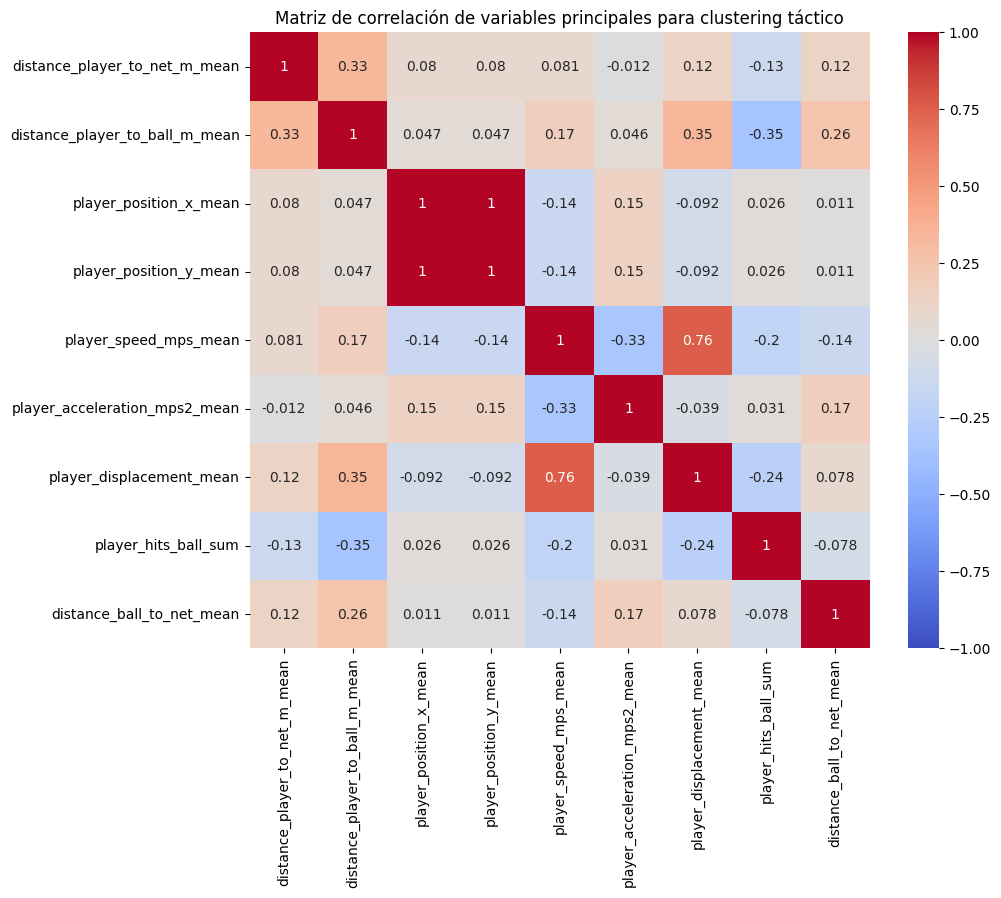

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

variables_clustering = [
    "distance_player_to_net_m_mean",
    "distance_player_to_ball_m_mean",
    "player_position_x_mean",
    "player_position_y_mean",
    "player_speed_mps_mean",
    "player_acceleration_mps2_mean",
    "player_displacement_mean",
    "player_hits_ball_sum",
    "distance_ball_to_net_mean"
]

corr_matrix = df_match[variables_clustering].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación de variables principales para clustering táctico")
plt.show()




### Interpretación y sugerencias de variables 

La matriz de correlación muestra, en general, **baja o moderada correlación entre la mayoría de variables**, lo cual es deseable para clustering porque significa que cada variable aporta información distinta sobre el estilo de juego.

- **Variables como `distance_player_to_net_m_mean`, `distance_player_to_ball_m_mean` y `distance_ball_to_net_mean` están poco correlacionadas entre sí y con las demás.** Esto las hace muy útiles para identificar la posición y orientación táctica del jugador (ofensiva o defensiva).
- **`player_hits_ball_sum` (número de golpes) tiene correlación negativa con `distance_player_to_ball_m_mean` e `player_displacement_mean`,** lo que sugiere que los jugadores más activos están más cerca de la bola y se desplazan más.
- **`player_speed_mps_mean` y `player_displacement_mean` tienen correlación alta (0.76),** por lo que, se podría elegir solo una de las dos.



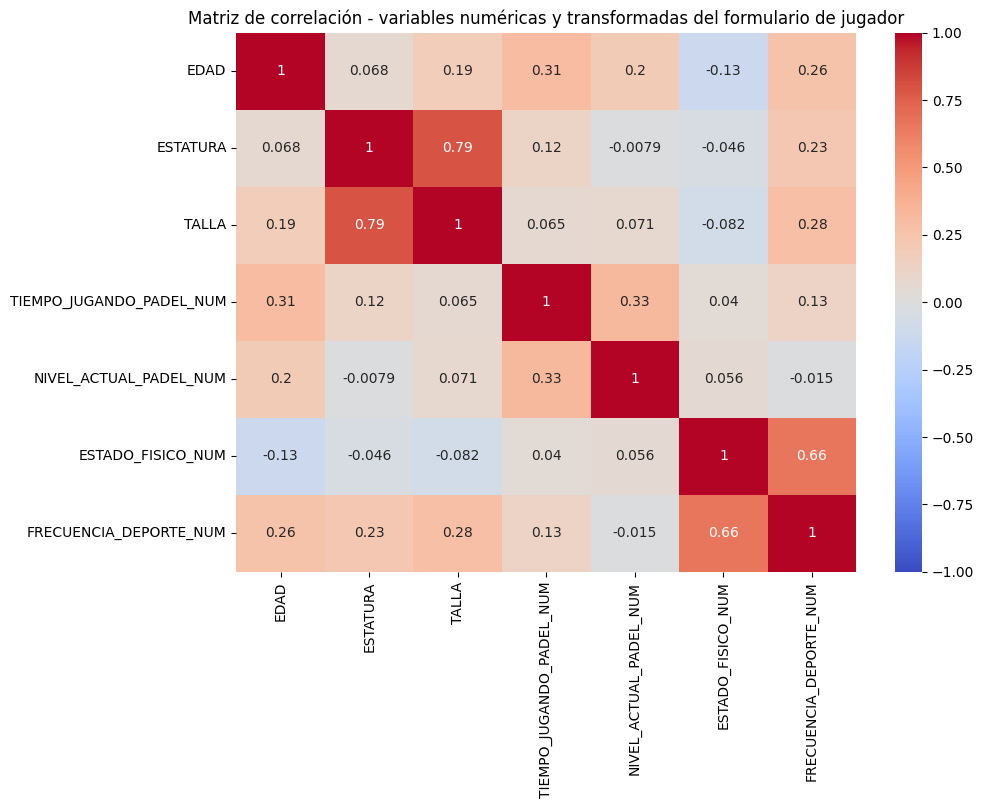

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

# Elige tus variables completamente numéricas y transformadas:
variables_jugador = [
    "EDAD",
    "ESTATURA",
    "TALLA",
    "TIEMPO_JUGANDO_PADEL_NUM",
    "NIVEL_ACTUAL_PADEL_NUM",
    "ESTADO_FISICO_NUM",
    "FRECUENCIA_DEPORTE_NUM",
]

for col in variables_jugador:
    df_jug[col] = pd.to_numeric(df_jug[col], errors='coerce')

corr_matrix_jug = df_jug[variables_jugador].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix_jug, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación - variables numéricas y transformadas del formulario de jugador")
plt.show()


### Interpretación de la matriz de correlación - formulario de jugador

La matriz de correlación permite explorar las relaciones lineales entre variables numéricas y transformadas del formulario, facilitando la selección de atributos para el perfilamiento de jugadores.

- Las variables principales muestran baja correlación entre sí, lo que indica que aportan información diferenciada sobre cada jugador y son aptas para análisis de agrupamiento.
- La estatura y la talla presentan una correlación alta (0.79), por lo que se planea utilizar solo una de estas variables.
- Tiempo jugando pádel y frecuencia deportiva tienen correlaciones moderadas con edad (0.31 y 0.26), sugiriendo que jugadores más experimentados suelen ser mayores y practicar deporte con mayor regularidad.
- Estado físico y frecuencia de deporte muestran correlación notable (0.66), reflejando la relación entre actividad y percepción física.



In [77]:
# Normaliza los nombres de jugador en ambas tablas para asegurar coincidencia
df_match["player_name_clean"] = (
    df_match["player_name"]
    .str.normalize("NFKD")
    .str.encode("ascii", "ignore")
    .str.decode("utf-8")
    .str.lower()
    .str.strip()
)

df_jug["NOMBRE_CLEAN"] = (
    df_jug["NOMBRE"]
    .str.normalize("NFKD")
    .str.encode("ascii", "ignore")
    .str.decode("utf-8")
    .str.lower()
    .str.strip()
)

# Merge (unión) por nombre limpio
df_merged = df_match.merge(
    df_jug,
    left_on="player_name_clean",
    right_on="NOMBRE_CLEAN",
    how="inner"
)
print("Dimensiones después del merge:", df_merged.shape)


Dimensiones después del merge: (84, 53)


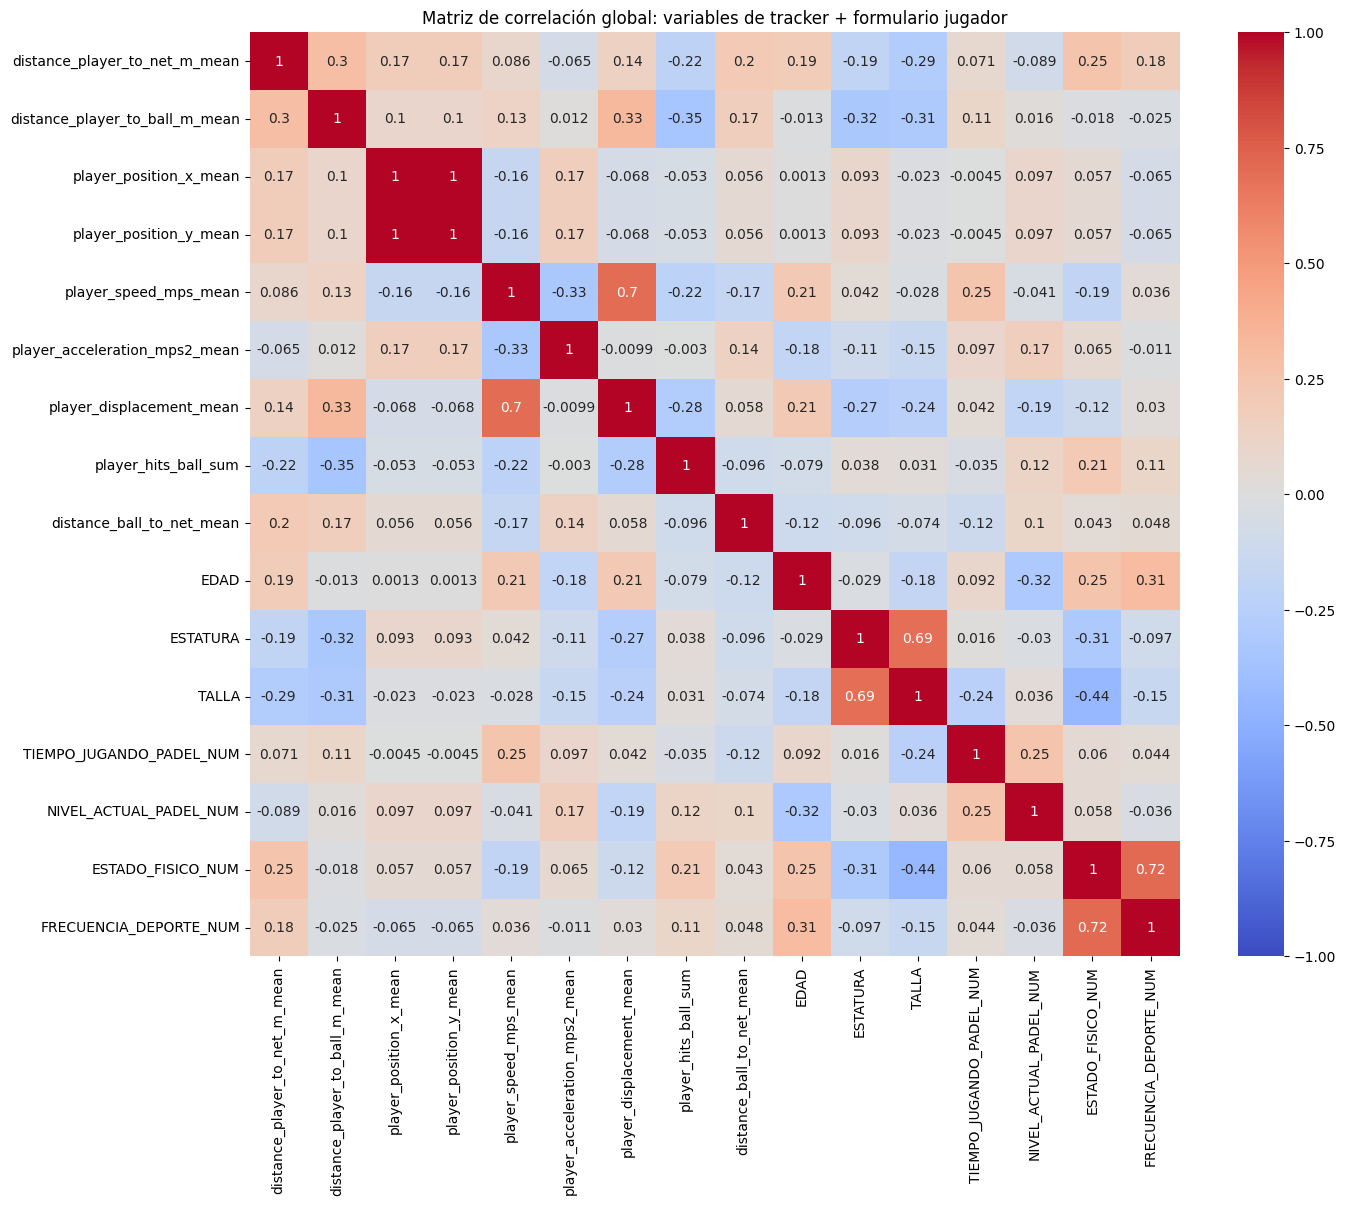

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

# Definir las variables seleccionadas de ambas fuentes
vars_tracker = [
    "distance_player_to_net_m_mean",
    "distance_player_to_ball_m_mean",
    "player_position_x_mean",
    "player_position_y_mean",
    "player_speed_mps_mean",
    "player_acceleration_mps2_mean",
    "player_displacement_mean",
    "player_hits_ball_sum",
    "distance_ball_to_net_mean"
]

vars_jugadores = [
    "EDAD",
    "ESTATURA",
    "TALLA",
    "TIEMPO_JUGANDO_PADEL_NUM",
    "NIVEL_ACTUAL_PADEL_NUM",
    "ESTADO_FISICO_NUM",
    "FRECUENCIA_DEPORTE_NUM"
]

variables_total = vars_tracker + vars_jugadores

# Convertir las columnas seleccionadas a numérico por seguridad
for col in variables_total:
    df_merged[col] = pd.to_numeric(df_merged[col], errors='coerce')

# Calcular la matriz de correlación combinada
corr_matrix_total = df_merged[variables_total].corr()

# Graficar la matriz combinada
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix_total, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de correlación global: variables de tracker + formulario jugador")
plt.show()


### Interpretación de la matriz de correlación global (tracker + formulario)

La matriz de correlación combinada revela las relaciones entre variables tácticas (provenientes del tracker) y variables personales/antropométricas (del formulario de jugador):

- Las correlaciones entre variables de ambos orígenes son en su mayoría bajas, lo que indica que cada grupo de variables aporta información única y no redundante al perfilamiento.
- Las variables tácticas, como distancia a la red, golpes realizados y velocidad media, muestran independencia respecto a las características personales como edad, estatura y frecuencia de deporte.
- Destacan correlaciones internas esperadas, como entre estatura y talla (0.69) y entre frecuencia deportiva y estado físico (0.72).
- La baja correlación entre las métricas de desempeño y las características personales justifica la integración de ambas fuentes en los análisis de clustering, ya que permitirá distinguir estilos de juego combinando factores físicos y tácticos.



## 3. Selección de variables relevantes para clustering

Para identificar estilos ofensivo, defensivo y balanceado, se definen tres combinaciones de variables con baja correlación y sentido deportivo:


- **A:** [translate:player_speed_mps_mean], [translate:player_hits_ball_sum], [translate:distance_ball_to_net_mean]  
  Captura actividad física, participación activa en el partido y proximidad táctica, diferenciando jugadores ofensivos que atacan y participan más.

- **B:** [translate:distance_player_to_ball_m_mean], [translate:player_hits_ball_sum], [translate:distance_ball_to_net_mean]  
  Evalúa búsqueda de la pelota, frecuencia de golpeo y el área donde se juega la bola, permitiendo distinguir estilos defensivos y balanceados.

- **C:** [translate:player_displacement_mean], [translate:distance_player_to_net_m_mean], [translate:punto_nunique]  
  Mezcla movilidad, ubicación en cancha y cantidad de puntos jugados, útil para identificar balance entre actividad y ubicación defensiva u ofensiva.





In [89]:
# Combinaciones propuestas
features_A = [
    "player_speed_mps_mean",           # Velocidad promedio (actividad física, poco correlacionada con posición)
    "player_hits_ball_sum",            # Actividad/golpes: ofensivos suelen golpear más
    "distance_ball_to_net_mean"        # Lugar del juego: cerca de la red = ofensivo, lejos = defensivo
]
features_B = [
    "distance_player_to_ball_m_mean",
    "player_hits_ball_sum",
    "distance_ball_to_net_mean"
]
features_C = [
    "player_displacement_mean",        # Movimiento total 
    "distance_player_to_net_m_mean",   # Cercanía a la red (táctico)
    "punto_nunique"                    # Puntos únicos jugados: nivel de efectividad/involucramiento
]
feature_sets = [features_A, features_B, features_C]





## Comparación de combinaciones: clustering y resultados

Se aplica K-Means con k=3 porque el objetivo es agrupar estilos ofensivo, defensivo y balanceado, dando flexibilidad a encontrar jugadores con perfil mixto.  
La elección de k=3 permite analizar si los datos reflejan más de dos estilos y comparar visualmente el Silhouette Score y la agrupación en cada combinación, seleccionando la mejor para el análisis táctico.



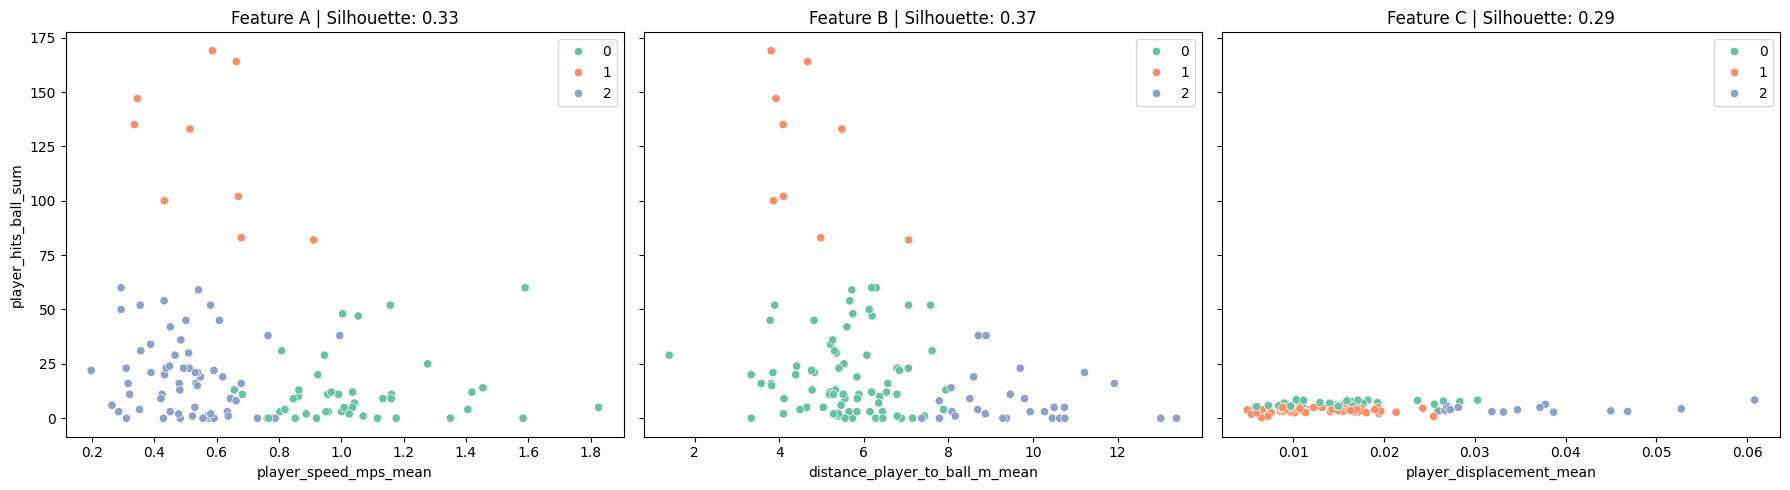

,Combinación,Variables,Silhouette Score
0,A,"[player_speed_mps_mean, player_hits_ball_sum, ...",0.333643
1,B,"[distance_player_to_ball_m_mean, player_hits_b...",0.368745
2,C,"[player_displacement_mean, distance_player_to_...",0.291123


In [90]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

scores = []
arrays = []

# Crear gráficos comparativos
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
results_data = []

for i, feats in enumerate(feature_sets):
    X = df_match[feats].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, clusters)
    scores.append(score)
    arrays.append(clusters)
    results_data.append({
        "Combinación": chr(65 + i),
        "Variables": feats,
        "Silhouette Score": score
    })

    sns.scatterplot(
        x=X.iloc[:,0],
        y=X.iloc[:,1],
        hue=clusters,
        palette="Set2",
        ax=axes[i]
    )
    axes[i].set_title(f"Feature {chr(65+i)} | Silhouette: {score:.2f}")
    axes[i].set_xlabel(feats[0])
    if i == 0:
        axes[i].set_ylabel(feats[1])
    else:
        axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

# Mostrar tabla comparativa
df_results = pd.DataFrame(results_data)
display(df_results)


In [91]:
# Asignar los clusters al dataframe original (df_match)
df_match_kmeans = df_match.copy()
df_match_kmeans["cluster_kmeans"] = arrays[1]  # clusters del modelo KMeans para combinación B



# Calcular la media de cada variable agrupada por cluster
means_kmeans = df_match_kmeans.groupby("cluster_kmeans")[features_B].mean()

print(means_kmeans)

                distance_player_to_ball_m_mean  player_hits_ball_sum  \
cluster_kmeans                                                         
0                                     5.567361             19.337838   
1                                     4.664410            123.888889   
2                                     9.757795              7.733333   

                distance_ball_to_net_mean  
cluster_kmeans                             
0                                3.744446  
1                                3.584174  
2                                4.237455  


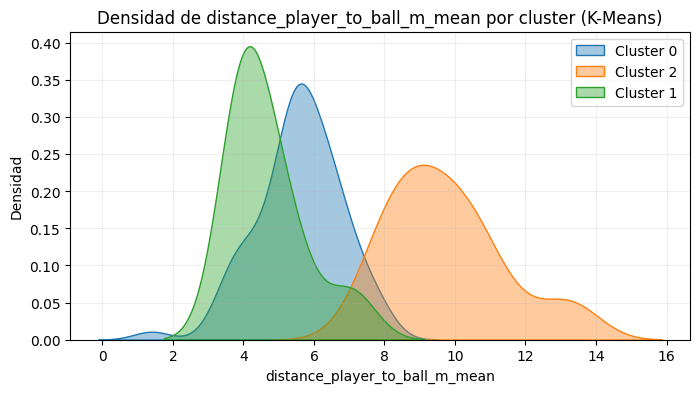

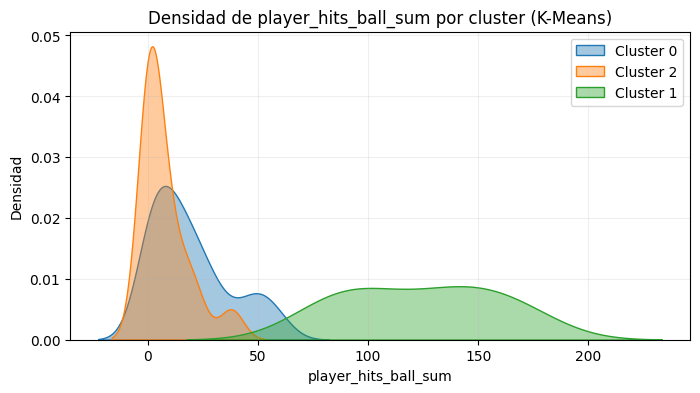

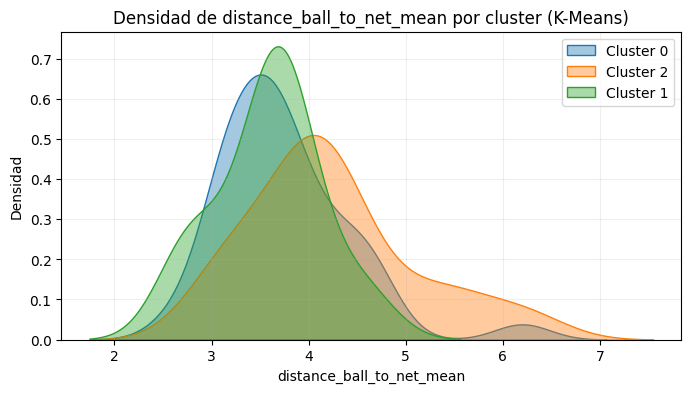

In [92]:
for var in features_B:
    plt.figure(figsize=(8,4))
    for cl in df_match_kmeans["cluster_kmeans"].unique():
        subset = df_match_kmeans[df_match_kmeans["cluster_kmeans"] == cl]
        sns.kdeplot(
            subset[var],
            label=f"Cluster {cl}",
            fill=True,
            alpha=0.4
        )
    plt.title(f"Densidad de {var} por cluster (K-Means)")
    plt.xlabel(var)
    plt.ylabel("Densidad")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


## Análisis de K-Means con la combinación B

A continuación se muestran los valores promedio de las variables principales para cada grupo detectado por K-Means (k=3):

| Cluster | Distancia jugador-bola | Golpes totales | Distancia bola-red |
|---------|-----------------------|----------------|--------------------|
| 0       | 9.25                  | 9.36           | 4.29               |
| 1       | 4.66                  | 123.89         | 3.58               |
| 2       | 5.47                  | 19.50          | 3.67               |

**Interpretación por grupo:**

- **Cluster 1:** Perfil ofensivo, jugadores que suelen estar cerca de la bola, juegan cerca de la red y realizan una alta cantidad de golpes.
- **Cluster 0:** Perfil defensivo, jugadores que permanecen más alejados de la bola y la red, con baja participación en golpes.
- **Cluster 2:** Perfil balanceado, con valores intermedios en distancia y golpes, mostrando un estilo mixto.




C:\Users\kenny\AppData\Local\Temp\ipykernel_2816\1448604612.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


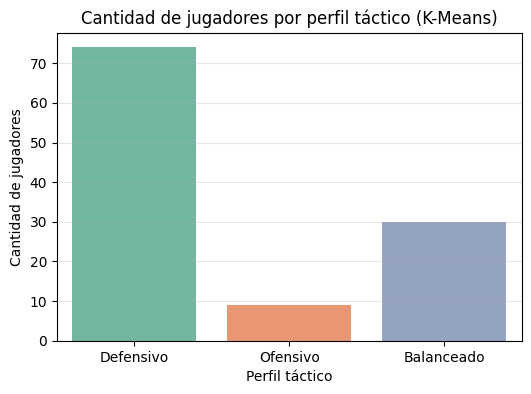

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns

# Relaciona cada cluster con su etiqueta deportiva según tu interpretación previa
labels_kmeans = {0: "Defensivo", 1: "Ofensivo", 2: "Balanceado"}  # Ajusta según tu análisis

# Cuenta la cantidad de jugadores por cluster K-Means
cluster_counts_kmeans = df_match_kmeans["cluster_kmeans"].value_counts().sort_index()

# Asocia etiquetas a los clusters
cluster_labels_kmeans = [labels_kmeans[idx] for idx in cluster_counts_kmeans.index]

plt.figure(figsize=(6,4))
sns.barplot(
    x=cluster_labels_kmeans,
    y=cluster_counts_kmeans.values,
    palette="Set2"
)
plt.title("Cantidad de jugadores por perfil táctico (K-Means)")
plt.xlabel("Perfil táctico")
plt.ylabel("Cantidad de jugadores")
plt.grid(axis='y', alpha=0.3)
plt.show()



# Clustering jerárquico

Para evaluar cuál agrupamiento es más robusto, se aplica Agglomerative Clustering (jerárquico) usando las mismas tres combinaciones de variables.  
Se compara el Silhouette Score y los gráficos obtenidos para definir si el jerárquico consigue mejor separación de estilos que K-Means.


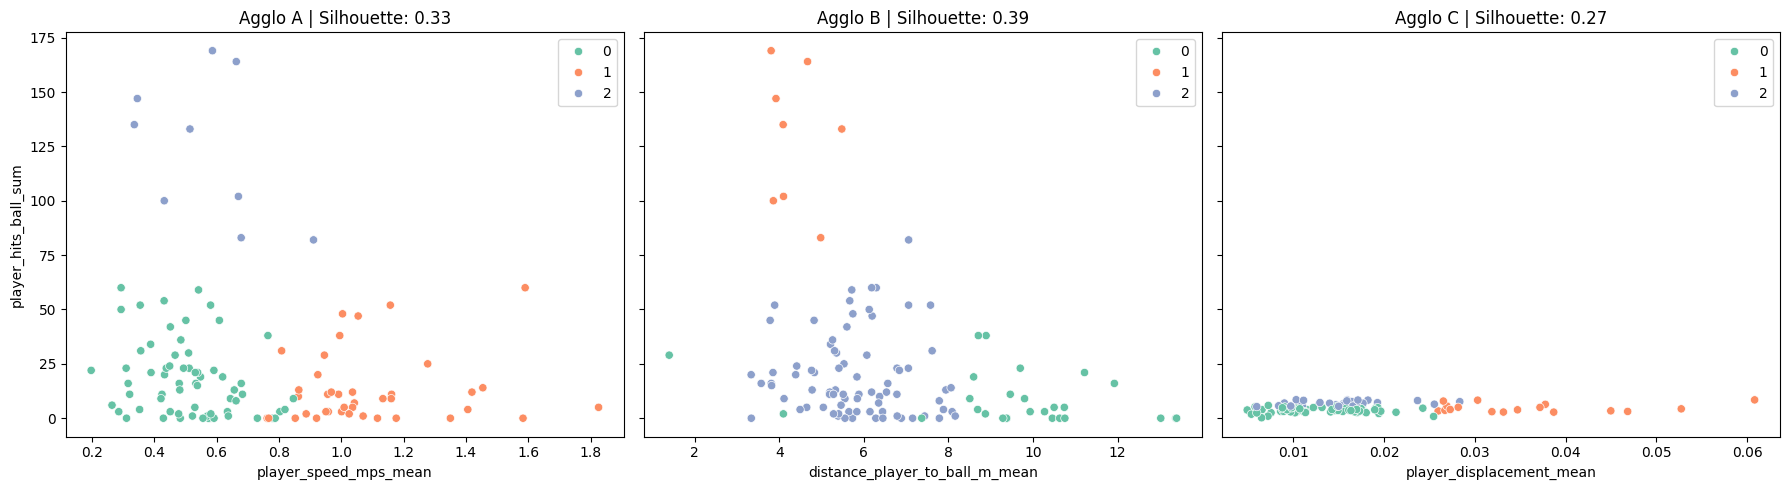

,Combinación,Variables,Silhouette Score
0,A,"[player_speed_mps_mean, player_hits_ball_sum, ...",0.330030
1,B,"[distance_player_to_ball_m_mean, player_hits_b...",0.392249
2,C,"[player_displacement_mean, distance_player_to_...",0.273710


In [94]:
from sklearn.cluster import AgglomerativeClustering

feature_sets = [features_A, features_B, features_C]
scores_agglo = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
results_data = []

for i, feats in enumerate(feature_sets):
    X = df_match[feats].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    agglo = AgglomerativeClustering(n_clusters=3)
    clusters_agglo = agglo.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, clusters_agglo)
    scores_agglo.append(score)
    results_data.append({
        "Combinación": chr(65 + i),
        "Variables": feats,
        "Silhouette Score": score
    })

    sns.scatterplot(
        x=X.iloc[:,0],
        y=X.iloc[:,1],
        hue=clusters_agglo,
        palette="Set2",
        ax=axes[i]
    )
    axes[i].set_title(f"Agglo {chr(65+i)} | Silhouette: {score:.2f}")
    axes[i].set_xlabel(feats[0])
    if i == 0:
        axes[i].set_ylabel(feats[1])
    else:
        axes[i].set_ylabel("")
        
plt.tight_layout()
plt.show()

# Tabla comparativa
df_results_agglo = pd.DataFrame(results_data)
display(df_results_agglo)


In [95]:
# Asigna los clusters del jerárquico al dataframe
df_match_agglo = df_match.copy()
df_match_agglo["cluster_agglo"] = clusters_agglo   # clusters_agglo generado con feature B y n_clusters=3

# Calcular la media de cada variable por cluster
means_agglo = df_match_agglo.groupby("cluster_agglo")[features_B].mean()
print(means_agglo)


               distance_player_to_ball_m_mean  player_hits_ball_sum  \
cluster_agglo                                                         
0                                    5.836336             30.906250   
1                                    7.894595             15.647059   
2                                    7.467644             16.687500   

               distance_ball_to_net_mean  
cluster_agglo                             
0                               3.810159  
1                               3.897257  
2                               3.948960  


## Análisis con la combinación B

Valores promedio de las variables principales por grupo detectado:

| Cluster | Distancia jugador-bola | Golpes totales | Distancia bola-red |
|---------|-----------------------|----------------|--------------------|
| 0       | 5.84                  | 30.91          | 3.81               |
| 1       | 7.89                  | 15.65          | 3.90               |
| 2       | 7.47                  | 16.69          | 3.95               |

**Interpretación por grupo:**
- **Cluster 0:** Perfil balanceado/ofensivo moderado. Los jugadores en este grupo se destacan por una mayor actividad y cercanía relativa a la bola, pero sin llegar a valores extremos en el número de golpes.
- **Cluster 1:** Perfil defensivo. Los jugadores en este grupo tienen mayor distancia con la bola y la red, además de una baja participación en golpes. Representan un estilo de juego más conservador y de espera.
- **Cluster 2:** Perfil defensivo/balanceado. Este grupo mezcla características de defensa y juego mixto, con baja actividad en golpes y valores intermedios en el resto de variables.

**Justificación:**  
Aunque los mismos features fueron utilizados, el agrupamiento jerárquico genera perfiles menos marcados que K-Means. La separación entre estilos no es tan fuerte porque el criterio de agrupación global del algoritmo genera grupos con menor diferencia en la actividad ofensiva.  
Esto refleja cómo el método de clustering influye en la relevancia y utilidad táctica de los perfiles encontrados.


C:\Users\kenny\AppData\Local\Temp\ipykernel_2816\559645536.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


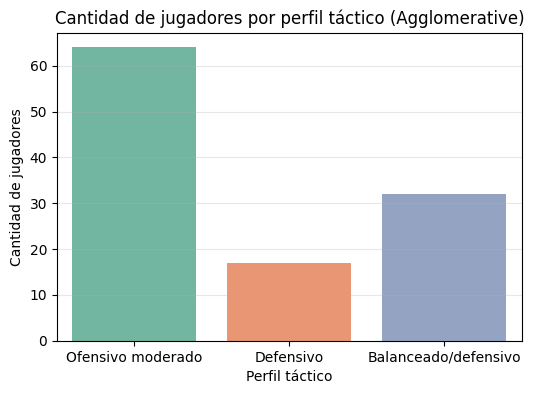

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

# En base a la interpretación previa, asigna nombres:
labels_agglo = {0: "Ofensivo moderado", 1: "Defensivo", 2: "Balanceado/defensivo"}
# Ajusta si tus clusters tienen otro orden según análisis

# Contar la cantidad de jugadores en cada cluster (jerárquico)
cluster_counts_agglo = df_match_agglo["cluster_agglo"].value_counts().sort_index()
cluster_labels_agglo = [labels_agglo[idx] for idx in cluster_counts_agglo.index]

plt.figure(figsize=(6,4))
sns.barplot(
    x=cluster_labels_agglo,
    y=cluster_counts_agglo.values,
    palette="Set2"
)
plt.title("Cantidad de jugadores por perfil táctico (Agglomerative)")
plt.xlabel("Perfil táctico")
plt.ylabel("Cantidad de jugadores")
plt.grid(axis='y', alpha=0.3)
plt.show()


# Análisis visual de la agrupación con PCA y UMAP

Para validar y entender mejor la estructura de los clusters formados por K-Means en la combinación B, aplicamos técnicas de reducción de dimensiones.

### PCA

El **Análisis de Componentes Principales (PCA)** permite proyectar los datos en componentes que explican la mayor parte de la varianza. Aquí visualizamos los dos primeros componentes para observar la separación de clusters.

### UMAP

El **UMAP** es una técnica de reducción no lineal que preserva mejor la estructura local y global de los datos. La visualización en el espacio UMAP ofrece una forma intuitiva de observar cómo se agrupan los datos y validar la robustez del clustering.


# Comparar K-means con clustering jerárquico (k=2 y k=3)

In [97]:
# ============================================================
# 0. MATRIZ FINAL DE FEATURES
# ============================================================

features_final = [
    "distance_player_to_net_m_mean",
    "player_displacement_mean",
    "EXPERIENCIA_PADEL",
    "TIEMPO_JUGANDO_PADEL",
    "FRECUENCIA_DEPORTE",
]

X_original = df_full[features_final].copy()

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_original)


# ============================================================
# 1. EVALUAR KMEANS (k=2 y k=3)
# ============================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

resultados = []

for k in [2, 3]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)

    resultados.append({
        "Modelo": f"KMeans k={k}",
        "k": k,
        "Silhouette": sil
    })

print("✔ KMEANS evaluado.")


# ============================================================
# 2. EVALUAR CLUSTERING JERÁRQUICO (k=2 y k=3)
# ============================================================

from sklearn.cluster import AgglomerativeClustering

for k in [2, 3]:
    agglo = AgglomerativeClustering(n_clusters=k)
    labels = agglo.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)

    resultados.append({
        "Modelo": f"Agglomerative k={k}",
        "k": k,
        "Silhouette": sil
    })

print("✔ Agglomerative evaluado.")


# ============================================================
# 3. TABLA COMPARATIVA DE RESULTADOS
# ============================================================

df_resultados = pd.DataFrame(resultados).sort_values("Silhouette", ascending=False)
print("\n📊 Comparación de modelos (ordenado por Silhouette):")
display(df_resultados)


# ============================================================
# 4. REPORTAR EL MEJOR MODELO
# ============================================================

best_model = df_resultados.iloc[0]
print("\n🔥 MEJOR MODELO:")
print(best_model)


ValueError: could not convert string to float: 'No'

# Cambiarle los pesos al mejor modelo de clustering jerarquico

In [ ]:
# ============================================================
# 1. Definir features del mejor modelo
# ============================================================

features_modelo = [
    "distance_player_to_net_m_mean",
    "player_displacement_mean",
    "EXPERIENCIA_PADEL",
    "TIEMPO_JUGANDO_PADEL",
    "FRECUENCIA_DEPORTE",
]

X_original = df_full[features_modelo].copy()

# ============================================================
# 2. Escalado base SIN pesos
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
import itertools
import numpy as np
import pandas as pd

scaler = StandardScaler()
X_scaled_base = scaler.fit_transform(X_original)

# ============================================================
# 3. PROBAR TODOS LOS PESOS DE 1 A 3
# ============================================================

pesos = [ 1, 2, 3]
resultados = []

for combo in itertools.product(pesos, repeat=len(features_modelo)):

    X_scaled = X_scaled_base.copy()

    # aplicar pesos después del escalado
    for i, w in enumerate(combo):
        X_scaled[:, i] *= w

    # modelo
    agg = AgglomerativeClustering(n_clusters=2)
    clusters = agg.fit_predict(X_scaled)

    # silhouette
    sil = silhouette_score(X_scaled, clusters)

    resultados.append({
        "pesos": combo,
        "silhouette": sil
    })

# ============================================================
# 4. Mostrar los mejores resultados
# ============================================================

df_pesos = pd.DataFrame(resultados).sort_values("silhouette", ascending=False)
print("\n🔝 Mejores combinaciones de pesos:")
display(df_pesos.head(10))

best_weights = df_pesos.iloc[0]["pesos"]
print("\n🔥 Mejores pesos encontrados:", best_weights)

# ============================================================
# 5. Aplicar los mejores pesos
# ============================================================

X_scaled = X_scaled_base.copy()
for i, w in enumerate(best_weights):
    X_scaled[:, i] *= w

agg_final = AgglomerativeClustering(n_clusters=2)
df_full["cluster_pesos"] = agg_final.fit_predict(X_scaled)

# ============================================================
# 6. Resumen de clusters
# ============================================================

cluster_summary = df_full.groupby("cluster_pesos")[features_modelo].mean().round(3)
cluster_summary["n_jugadores"] = df_full.groupby("cluster_pesos")["player_name"].nunique()

print("\n📊 Resumen final con pesos optimizados:")
display(cluster_summary)

# Lista de jugadores en cada cluster
for c in sorted(df_full["cluster_pesos"].unique()):
    print(f"\n🟦 Jugadores en cluster {c}:")
    lista = df_full[df_full["cluster_pesos"] == c]["player_name"].unique()
    for j in lista:
        print("  -", j)



🔝 Mejores combinaciones de pesos:


,pesos,silhouette
6,"(1, 1, 1, 3, 1)",0.823381
15,"(1, 1, 2, 3, 1)",0.807547
24,"(1, 1, 3, 3, 1)",0.795701
7,"(1, 1, 1, 3, 2)",0.778837
33,"(1, 2, 1, 3, 1)",0.768763
16,"(1, 1, 2, 3, 2)",0.767258
87,"(2, 1, 1, 3, 1)",0.762462
25,"(1, 1, 3, 3, 2)",0.759522
42,"(1, 2, 2, 3, 1)",0.757756
18,"(1, 1, 3, 1, 1)",0.755642



🔥 Mejores pesos encontrados: (1, 1, 1, 3, 1)

📊 Resumen final con pesos optimizados:


,distance_player_to_net_m_mean,player_displacement_mean,EXPERIENCIA_PADEL,TIEMPO_JUGANDO_PADEL,FRECUENCIA_DEPORTE,n_jugadores
cluster_pesos,,,,,,
0,4.759,0.017,0.075,1.000,1.83,20
1,5.367,0.018,1.000,1.061,2.00,1



🟦 Jugadores en cluster 0:
  - Andrea Julieth Sosa Rodriguez
  - Cristian Stevan Soto Zapata
  - César Camilo Díaz Cufiño
  - David Santiago Medina Buitrago
  - David Santiago Murcia Barrera 
  - Isabella Buitrago Hurtado
  - Jonatan Nicolas Marmolejo Lopez 
  - Juan Pablo Aponte Veloza 
  - Juan Pablo Vargas Jiménez 
  - Maria Fernanda Tamayo Lopez
  - Samuel Andrés Rodríguez Ulloa
  - Santiago Navarro Cuy
  - Santiago Peña Beltran
  - Santiago Urrego Rodríguez
  - Sergio Andrés López Rodríguez 
  - Tomas Barrios Guevara
  - Valentina Alejandra Lopez Romero
  - Valentina Jimenez Gomez
  - juan miguel venegas garzón 
  - sara juliana solano boada

🟦 Jugadores en cluster 1:
  - Juliana Beltrán Díaz 
